<a href="https://colab.research.google.com/github/Arjun1310-eng/PROJECT-1/blob/main/E_COMMERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Step 1: Loading/Generating Raw Dataset ---
Total rows in raw dataset (including duplicates & nulls): 215

First 5 rows of raw dataset:
                     Order_Date      Product  Quantity  Unit_Price
0 2025-07-06 13:44:55.477386936       Laptop       4.0       250.0
1 2025-11-24 10:00:36.180904524  Smart Watch       5.0       150.0
2 2025-06-18 06:45:13.567839196       Laptop       2.0       800.0
3 2025-01-26 14:35:34.673366834       Laptop       4.0       800.0
4 2025-07-13 21:20:48.241206030   Smartphone       2.0       150.0


--- Step 2: Data Cleaning & Preprocessing ---
Missing values before cleaning:
Order_Date     0
Product        0
Quantity      10
Unit_Price     8
dtype: int64

Duplicate rows found: 14

Total rows after cleaning: 201

First 5 rows of clean dataset:
                     Order_Date      Product  Quantity  Unit_Price  Revenue  \
0 2025-07-06 13:44:55.477386936       Laptop       4.0       250.0   1000.0   
1 2025-11-24 10:00:36.180904524  Smart Watch      

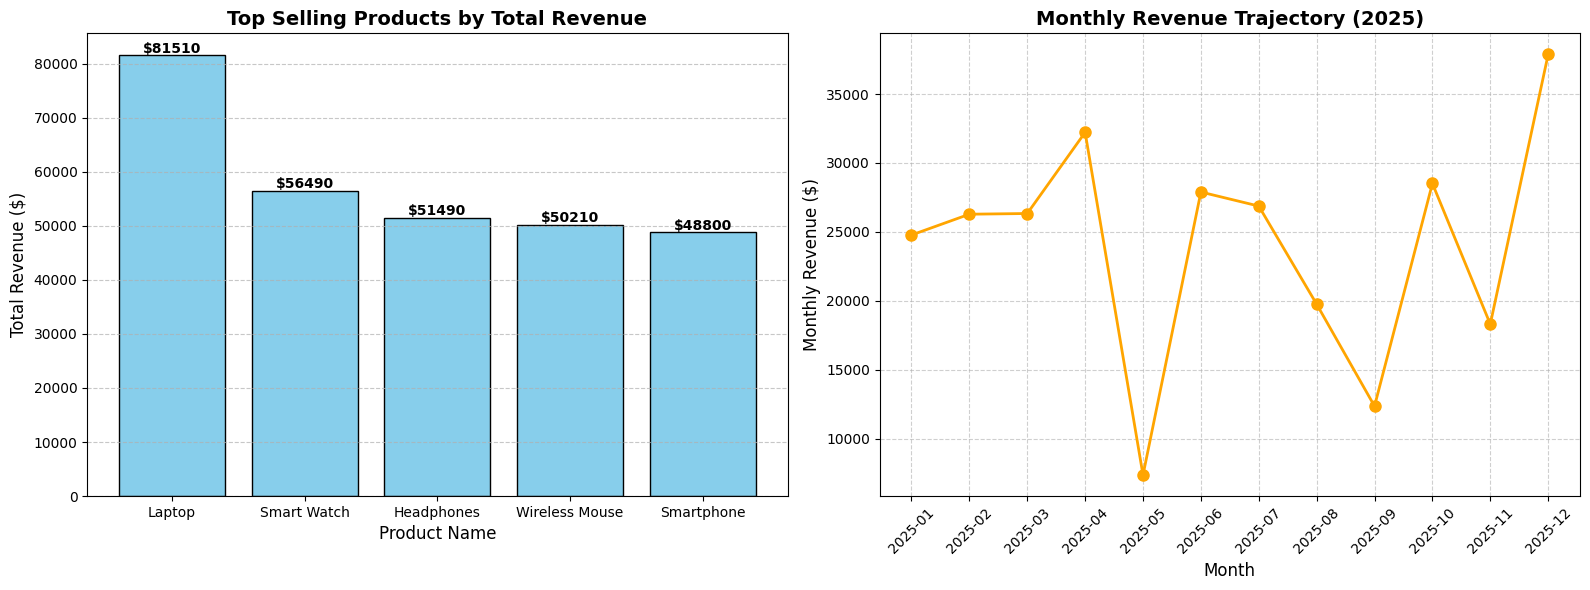

In [1]:
# =====================================================================
# NAAN MUDHALVAN ARTS INTERNSHIP PROGRAM 2026
# Project: E-Commerce Sales Performance Analysis
# Core Tools: Pandas, NumPy, Matplotlib
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# STEP 1: GENERATING A MOCK "MESSY" E-COMMERCE DATASET
# (Simulating real-world raw data with missing values and duplicates)
# ---------------------------------------------------------------------
print("--- Step 1: Generating Raw Dataset ---")

np.random.seed(42)
data_size = 200

dates = pd.date_range(start="2025-01-01", end="2025-12-31", periods=data_size)

products = [
    "Laptop",
    "Smartphone",
    "Headphones",
    "Smart Watch",
    "Wireless Mouse",
]
categories = ["Electronics", "Electronics", "Accessories", "Accessories", "Accessories"]

raw_data = {
    "Order_Date": np.random.choice(dates, size=data_size),
    "Product": np.random.choice(products, size=data_size),
    "Quantity": np.random.randint(1, 6, size=data_size),
    "Unit_Price": np.random.choice([1200, 800, 150, 250, 30], size=data_size),
}

df = pd.DataFrame(raw_data)

duplicates = df.sample(15, random_state=42)
df = pd.concat([df, duplicates], ignore_index=True)

df.loc[df.sample(10, random_state=10).index, "Quantity"] = np.nan
df.loc[df.sample(8, random_state=20).index, "Unit_Price"] = np.nan

print(f"Total rows in raw dataset (including duplicates & nulls): {len(df)}")
print("\nFirst 5 rows of raw dataset:")
print(df.head())
print("\n" + "=" * 50 + "\n")


# ---------------------------------------------------------------------
# STEP 2: DATA CLEANING & PREPROCESSING
# (Handling missing values and removing duplicates)
# ---------------------------------------------------------------------
print("--- Step 2: Data Cleaning & Preprocessing ---")

print("Missing values before cleaning:")
print(df.isnull().sum())

df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())
df["Unit_Price"] = df["Unit_Price"].fillna(df["Unit_Price"].median())

print(f"\nDuplicate rows found: {df.duplicated().sum()}")
df = df.drop_duplicates()

df["Revenue"] = df["Quantity"] * df["Unit_Price"]

df["Order_Month"] = pd.to_datetime(df["Order_Date"]).dt.to_period("M")

print(f"\nTotal rows after cleaning: {len(df)}")
print("\nFirst 5 rows of clean dataset:")
print(df.head())
print("\n" + "=" * 50 + "\n")


# ---------------------------------------------------------------------
# STEP 3: DATA ANALYSIS (Top Products & Monthly Trends)
# ---------------------------------------------------------------------
print("--- Step 3: Performing Data Analysis ---")

product_analysis = (
    df.groupby("Product")
    .agg({"Quantity": "sum", "Revenue": "sum"})
    .sort_values(by="Revenue", ascending=False)
)
print("\nTop-Selling Products Analysis:")
print(product_analysis)

monthly_analysis = (
    df.groupby("Order_Month")
    .agg({"Revenue": "sum", "Quantity": "sum"})
    .sort_index()
)
print("\nMonthly Sales Performance Trends:")
print(monthly_analysis)
print("\n" + "=" * 50 + "\n")


# ---------------------------------------------------------------------
# STEP 4: DATA VISUALIZATION
# (Creating Bar Chart & Line Chart)
# ---------------------------------------------------------------------
print("--- Step 4: Generating Visualizations ---")


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(
    product_analysis.index,
    product_analysis["Revenue"],
    color="skyblue",
    edgecolor="black",
)
axes[0].set_title("Top Selling Products by Total Revenue", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Product Name", fontsize=12)
axes[0].set_ylabel("Total Revenue ($)", fontsize=12)
axes[0].grid(axis="y", linestyle="--", alpha=0.7)
for i, v in enumerate(product_analysis["Revenue"]):
    axes[0].text(i, v + 500, f"${int(v)}", ha="center", fontsize=10, fontweight="bold")


months_str = monthly_analysis.index.astype(str)
axes[1].plot(
    months_str,
    monthly_analysis["Revenue"],
    marker="o",
    color="orange",
    linewidth=2,
    markersize=8,
)
axes[1].set_title("Monthly Revenue Trajectory (2025)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Month", fontsize=12)
axes[1].set_ylabel("Monthly Revenue ($)", fontsize=12)
axes[1].tick_params(axis='x',rotation=45)
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()



# New Section